# 🐪 REDAT Smart Livestock
## AI-Powered Early Warning and Monitoring System for Camel Farmers in Al Qua'a, UAE

---

**Project:** REDAT / Tatweer Competition  
**Goal:** Classify camel health status from IoT sensor data using multiple ML models  
**Target Classes:** `healthy` · `heat_stress` · `possible_illness` · `low_activity`

---

### 📋 Notebook Sections
| # | Section |
|---|---|
| 1 | Environment Setup & Imports |
| 2 | Data Loading & Exploration (EDA) |
| 3 | Data Cleaning & Preprocessing |
| 4 | Feature Engineering |
| 5 | Train / Validation / Test Split |
| 6 | Model 1 — Decision Tree (Baseline) |
| 7 | Model 2 — Random Forest |
| 8 | Model 3 — XGBoost |
| 9 | Model 4 — LightGBM |
| 10 | Model 5 — CatBoost |
| 11 | Hyperparameter Tuning (Best Models) |
| 12 | Final Model Comparison & Selection |
| 13 | Save Best Model |

---
## Section 1 — Environment Setup & Imports

In [1]:
!pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn optuna joblib imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 22.1 MB/s eta 0:00:00


In [2]:
# ─── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ─── Sklearn – Preprocessing ─────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV, GridSearchCV
)
from sklearn.pipeline import Pipeline

# ─── Sklearn – Models ────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier

# ─── Sklearn – Metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

# ─── Ensemble / Boosting Models ──────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ─── Imbalanced Data ─────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ─── Optuna for Hyperparameter Tuning ────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── Plotting Style ──────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']
CLASS_LABELS = ['healthy', 'heat_stress', 'possible_illness', 'low_activity']

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All libraries loaded successfully.')
print(f'   numpy   {np.__version__}')
print(f'   pandas  {pd.__version__}')

✅ All libraries loaded successfully.
   numpy   2.0.2
   pandas  2.2.2


---
## Section 2 — Data Loading & Exploratory Data Analysis (EDA)

In [3]:
# ─── Load Dataset ────────────────────────────────────────────────────────────
DATA_PATH = '/content/dataset_modified.csv'
df = pd.read_csv(DATA_PATH)

print('=' * 55)
print('  🐪  REDAT SMART LIVESTOCK — DATASET OVERVIEW')
print('=' * 55)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print('=' * 55)
df.head(10)

  🐪  REDAT SMART LIVESTOCK — DATASET OVERVIEW
  Rows    : 10,234
  Columns : 9


,body_temp,activity_level,heart_rate,movement_km,ambient_temp,humidity,water_intake,time_of_day,label
0,37.809080,67.0,65.0,4.89,38.89,21.98,16.85,morning,healthy
1,37.771286,86.0,47.0,5.01,19.19,22.87,13.09,morning,healthy
2,40.601353,86.0,80.0,4.52,35.40,51.30,14.43,evening,healthy
3,38.446448,62.0,50.0,5.43,36.32,18.34,20.72,afternoon,healthy
4,38.594437,75.0,39.0,6.01,26.22,37.61,12.20,afternoon,healthy
5,37.774442,87.0,57.0,5.46,40.35,36.04,16.70,afternoon,healthy
6,37.912180,43.0,49.0,2.95,33.24,14.04,23.36,morning,low_activity
7,38.934882,82.0,78.0,6.63,35.60,79.71,11.08,morning,healthy
8,38.118547,69.0,46.0,5.60,42.13,12.26,17.74,night,healthy
9,40.351917,49.0,76.0,3.33,33.67,33.07,12.92,morning,possible_illness


In [4]:
# ─── Data Types & Basic Info ──────────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10234 entries, 0 to 10233
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   body_temp       10234 non-null  float64
 1   activity_level  10234 non-null  float64
 2   heart_rate      10234 non-null  float64
 3   movement_km     10234 non-null  float64
 4   ambient_temp    10234 non-null  float64
 5   humidity        10234 non-null  float64
 6   water_intake    10234 non-null  float64
 7   time_of_day     10234 non-null  object 
 8   label           10234 non-null  object 
dtypes: float64(7), object(2)
memory usage: 719.7+ KB


In [5]:
# ─── Statistical Summary ─────────────────────────────────────────────────────
df.describe().round(3)

,body_temp,activity_level,heart_rate,movement_km,ambient_temp,humidity,water_intake
count,10234.000,10234.000,10234.000,10234.000,10234.000,10234.000,10234.000
mean,39.051,51.047,65.275,3.285,36.091,40.309,16.336
std,1.237,28.791,16.771,2.025,8.965,16.624,3.801
min,36.000,0.000,30.000,0.000,15.000,5.000,1.500
25%,38.190,26.000,53.000,1.630,29.260,28.750,13.860
50%,38.904,54.000,64.000,3.350,36.535,40.360,16.370
75%,39.805,75.000,76.000,4.800,43.380,51.690,18.880
max,43.500,100.000,130.000,10.530,50.000,95.340,32.140


In [6]:
# ─── Missing Values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
body_temp         0
activity_level    0
heart_rate        0
movement_km       0
ambient_temp      0
humidity          0
water_intake      0
time_of_day       0
label             0
dtype: int64

Total missing: 0


Class Distribution:
------------------------------------------
  healthy               5600  (54.7%)  ███████████████████████████
  heat_stress           2064  (20.2%)  ██████████
  low_activity          1505  (14.7%)  ███████
  possible_illness      1065  (10.4%)  █████


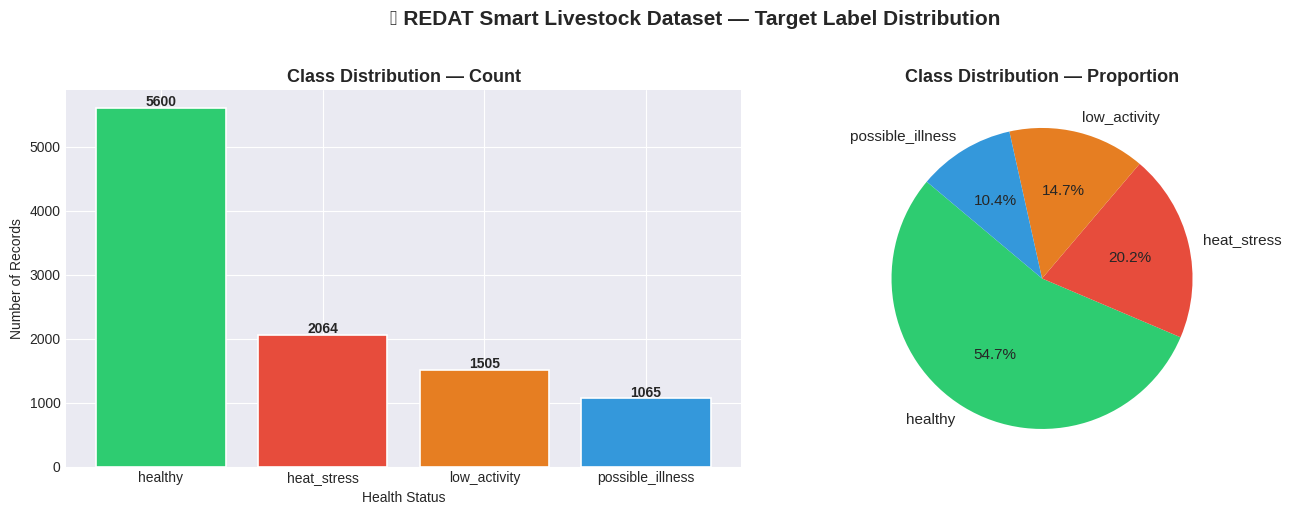

In [7]:
# ─── Class Distribution ───────────────────────────────────────────────────────
class_counts = df['label'].value_counts()
class_pct    = df['label'].value_counts(normalize=True) * 100

print('Class Distribution:')
print('-' * 42)
for cls, cnt, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    bar = '█' * int(pct // 2)
    print(f'  {cls:<20} {cnt:>5}  ({pct:.1f}%)  {bar}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=PALETTE, edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Health Status')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('🐪 REDAT Smart Livestock Dataset — Target Label Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

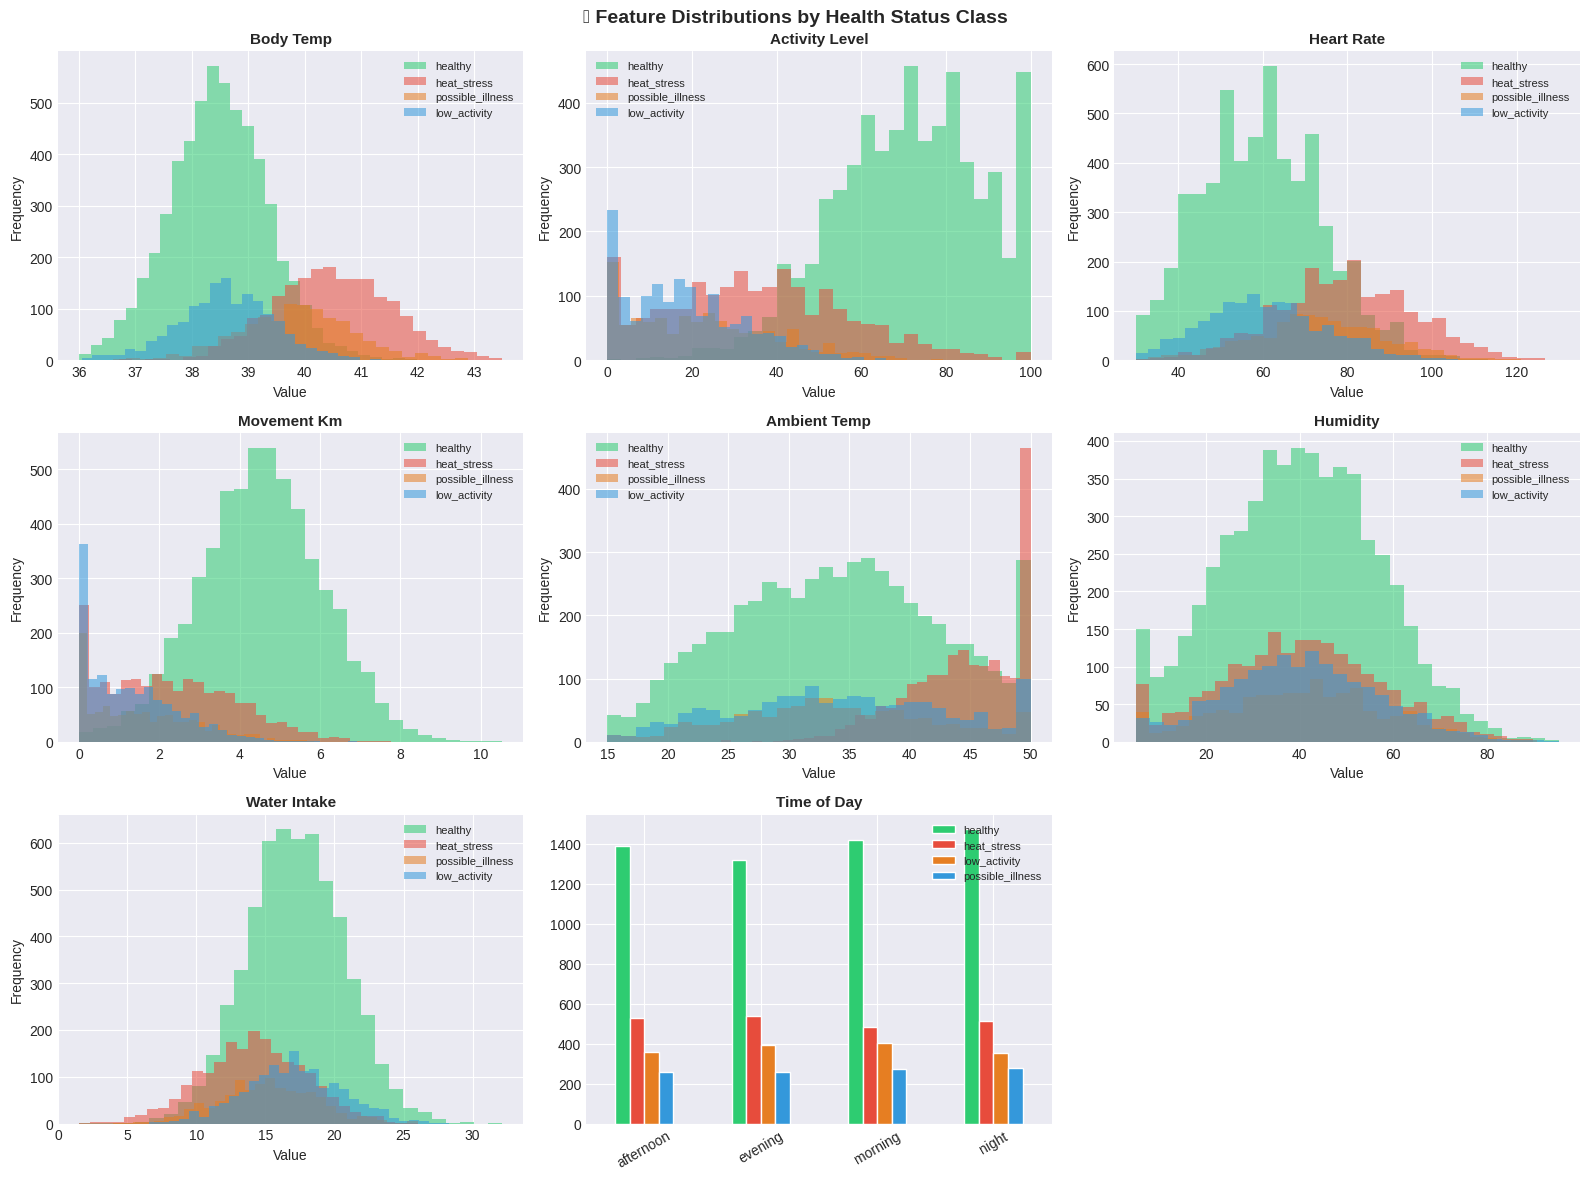

In [8]:
# ─── Feature Distributions by Class ──────────────────────────────────────────
numeric_features = ['body_temp', 'activity_level', 'heart_rate',
                    'movement_km', 'ambient_temp', 'humidity', 'water_intake']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    for j, (cls, color) in enumerate(zip(CLASS_LABELS, PALETTE)):
        subset = df[df['label'] == cls][feat]
        axes[i].hist(subset, bins=30, alpha=0.55, color=color, label=cls, edgecolor='none')
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

# Time of day – categorical
tod_cls = df.groupby(['time_of_day', 'label']).size().unstack(fill_value=0)
tod_cls.plot(kind='bar', ax=axes[7], color=PALETTE, edgecolor='white')
axes[7].set_title('Time of Day', fontsize=11, fontweight='bold')
axes[7].set_xlabel('')
axes[7].tick_params(axis='x', rotation=30)
axes[7].legend(fontsize=8)
axes[8].axis('off')

plt.suptitle('🐪 Feature Distributions by Health Status Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

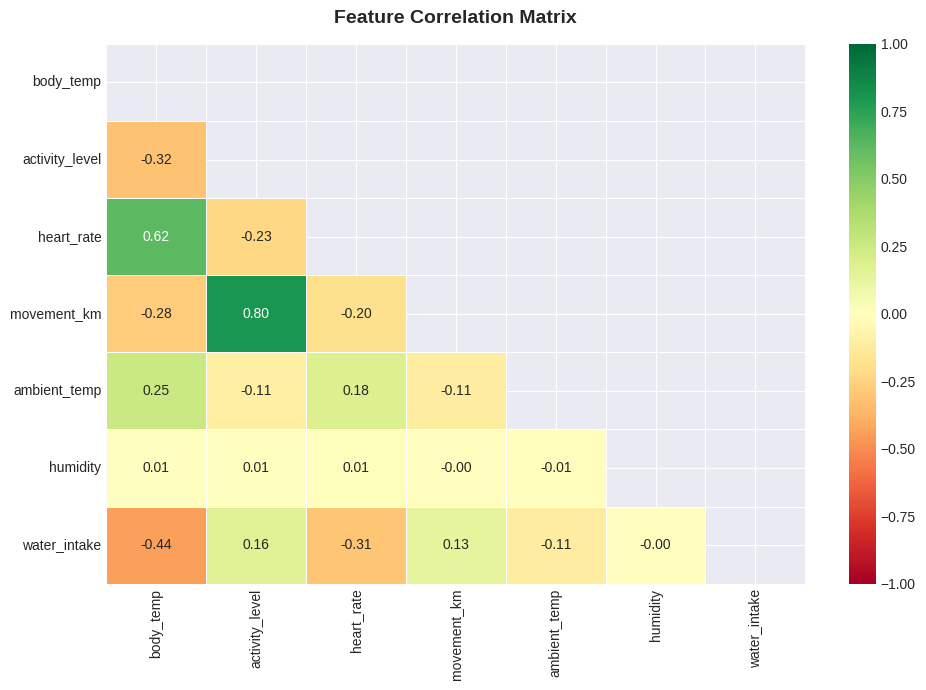

In [9]:
# ─── Correlation Heatmap ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
corr_matrix = df[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 10}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('03_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

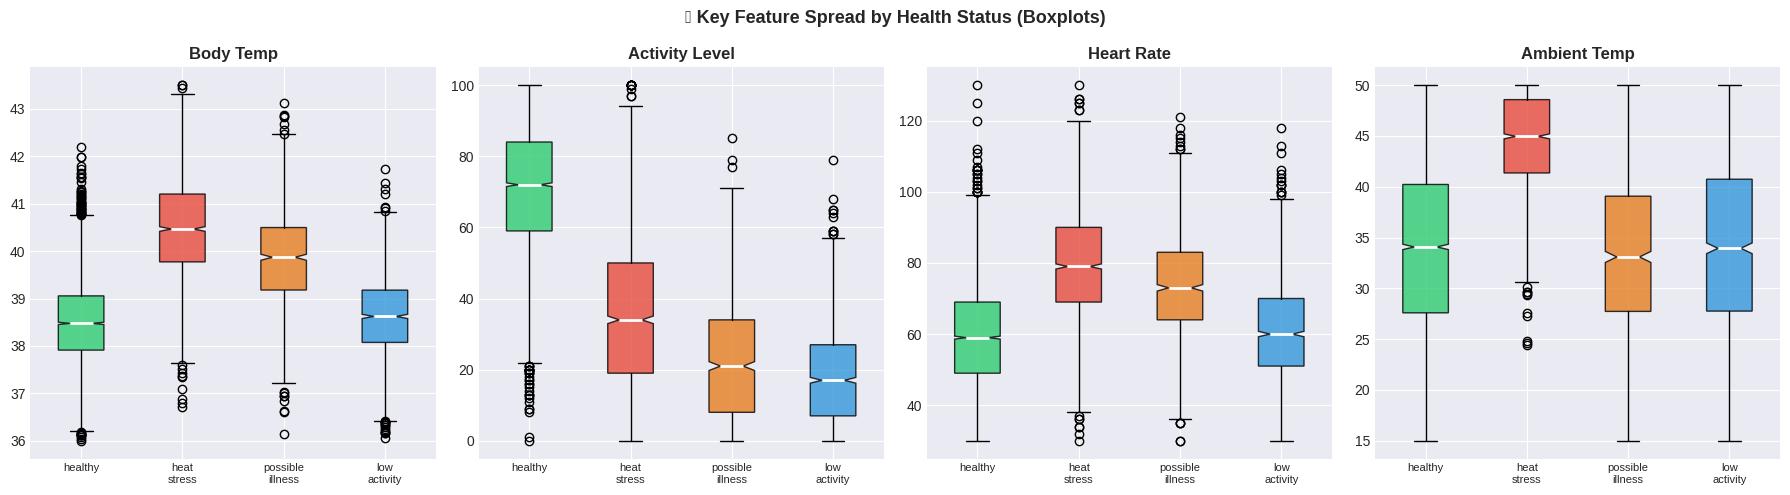

In [10]:
# ─── Boxplots — Key Features vs Class ────────────────────────────────────────
key_features = ['body_temp', 'activity_level', 'heart_rate', 'ambient_temp']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, key_features):
    data_by_class = [df[df['label'] == cls][feat].values for cls in CLASS_LABELS]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels([c.replace('_', '\n') for c in CLASS_LABELS], fontsize=8)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')

plt.suptitle('🐪 Key Feature Spread by Health Status (Boxplots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 3 — Data Cleaning & Preprocessing

In [11]:
# ─── Step 3.1: Duplicate Check ────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'  → Removed {dupes} duplicates. New shape: {df.shape}')
else:
    print('  → No duplicates found. ✅')

Duplicate rows: 0
  → No duplicates found. ✅


In [12]:
# ─── Step 3.2: Missing Value Treatment ───────────────────────────────────────
# Fill numeric with median, categorical with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            fill_val = df[col].median()
            df[col].fillna(fill_val, inplace=True)
            print(f'  {col}: filled {df[col].isnull().sum()} NaNs with median ({fill_val:.2f})')
        else:
            fill_val = df[col].mode()[0]
            df[col].fillna(fill_val, inplace=True)
            print(f'  {col}: filled NaNs with mode ("{fill_val}")')

print(f'Missing values after treatment: {df.isnull().sum().sum()}  ✅')

Missing values after treatment: 0  ✅


In [13]:
# ─── Step 3.3: Outlier Detection (IQR Method) ─────────────────────────────────
print('Outlier counts per numeric feature (IQR method):')
print('-' * 40)
outlier_summary = {}
for feat in numeric_features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_summary[feat] = n_out
    print(f'  {feat:<20}  {n_out:>4} outliers  [{lower:.2f} – {upper:.2f}]')

print('\n⚠️  Note: Outliers are KEPT — they may represent genuine')
print('   medical events (fever spikes, extreme heat stress).')
print('   The 10% noise injected in data generation mimics real-world variance.')

Outlier counts per numeric feature (IQR method):
----------------------------------------
  body_temp              111 outliers  [35.77 – 42.23]
  activity_level           0 outliers  [-47.50 – 148.50]
  heart_rate              69 outliers  [18.50 – 110.50]
  movement_km              4 outliers  [-3.12 – 9.55]
  ambient_temp             0 outliers  [8.08 – 64.56]
  humidity                25 outliers  [-5.66 – 86.10]
  water_intake           100 outliers  [6.33 – 26.41]

⚠️  Note: Outliers are KEPT — they may represent genuine
   medical events (fever spikes, extreme heat stress).
   The 10% noise injected in data generation mimics real-world variance.


In [14]:
# ─── Step 3.4: Encode Categorical Feature (time_of_day) ──────────────────────
# We use ordinal encoding reflecting the time sequence
time_order = {'morning': 0, 'afternoon': 1, 'evening': 2, 'night': 3}
df['time_of_day_enc'] = df['time_of_day'].map(time_order)

print('time_of_day encoding:')
print(df[['time_of_day', 'time_of_day_enc']].drop_duplicates().sort_values('time_of_day_enc').to_string(index=False))

time_of_day encoding:
time_of_day  time_of_day_enc
    morning                0
  afternoon                1
    evening                2
      night                3


In [15]:
# ─── Step 3.5: Encode Target Label ───────────────────────────────────────────
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label encoding mapping:')
for k, v in label_map.items():
    print(f'  {k:<20} → {v}')

Label encoding mapping:
  healthy              → 0
  heat_stress          → 1
  low_activity         → 2
  possible_illness     → 3


---
## Section 4 — Feature Engineering

In [16]:
# ─── Step 4.1: Derived / Interaction Features ─────────────────────────────────

# Heat Index: combine body_temp and ambient_temp
df['heat_index'] = df['body_temp'] + 0.33 * df['ambient_temp']

# Temp-Activity Ratio: high temp + low activity = danger signal
df['temp_activity_ratio'] = df['body_temp'] / (df['activity_level'] + 1)

# Hydration Stress: low water intake relative to ambient heat
df['hydration_stress'] = df['ambient_temp'] / (df['water_intake'] + 1)

# Mobility Score: heart rate relative to movement
df['mobility_score'] = df['movement_km'] * df['activity_level']

# Fever Flag: binary – body temp > 40°C is clinically significant
df['fever_flag'] = (df['body_temp'] > 40.0).astype(int)

# Critical Ambient: ambient temp > 43°C is extreme for UAE summer
df['critical_ambient'] = (df['ambient_temp'] > 43.0).astype(int)

new_features = ['heat_index', 'temp_activity_ratio', 'hydration_stress',
                'mobility_score', 'fever_flag', 'critical_ambient']
print('New engineered features:')
print(df[new_features].describe().round(3))

New engineered features:
       heat_index  temp_activity_ratio  hydration_stress  mobility_score  \
count   10234.000            10234.000         10234.000       10234.000   
mean       50.961                2.855             2.227         214.149   
std         3.483                7.609             0.946         191.640   
min        41.783                0.358             0.580           0.000   
25%        48.289                0.510             1.605          38.815   
50%        50.915                0.707             2.075         175.750   
75%        53.701                1.448             2.655         345.225   
max        59.980               43.199            17.447        1031.940   

       fever_flag  critical_ambient  
count   10234.000         10234.000  
mean        0.213             0.264  
std         0.410             0.441  
min         0.000             0.000  
25%         0.000             0.000  
50%         0.000             0.000  
75%         0.000       

In [17]:
# ─── Step 4.2: Final Feature Set ─────────────────────────────────────────────
FEATURE_COLS = (
    numeric_features
    + ['time_of_day_enc']
    + new_features
)
TARGET_COL = 'label_enc'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'\nFeatures used ({len(FEATURE_COLS)}):')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:>2}. {f}')

Feature matrix shape : (10234, 14)
Target vector shape  : (10234,)

Features used (14):
   1. body_temp
   2. activity_level
   3. heart_rate
   4. movement_km
   5. ambient_temp
   6. humidity
   7. water_intake
   8. time_of_day_enc
   9. heat_index
  10. temp_activity_ratio
  11. hydration_stress
  12. mobility_score
  13. fever_flag
  14. critical_ambient


---
## Section 5 — Train / Validation / Test Split

In [18]:
# ─── 70% Train | 15% Validation | 15% Test ───────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=y_trainval
)

print('Dataset split summary:')
print(f'  Training    : {X_train.shape[0]:>5} rows  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Validation  : {X_val.shape[0]:>5} rows  ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'  Test        : {X_test.shape[0]:>5} rows  ({X_test.shape[0]/len(X)*100:.1f}%)')

Dataset split summary:
  Training    :  7163 rows  (70.0%)
  Validation  :  1535 rows  (15.0%)
  Test        :  1536 rows  (15.0%)


In [19]:
# ─── Handle Class Imbalance with SMOTE (Training Set Only) ────────────────────
print('Class distribution BEFORE SMOTE (training set):')
for cls_id, cls_name in enumerate(le.classes_):
    count = (y_train == cls_id).sum()
    print(f'  {cls_name:<20} {count}')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nClass distribution AFTER SMOTE (training set):')
for cls_id, cls_name in enumerate(le.classes_):
    count = (y_train_sm == cls_id).sum()
    print(f'  {cls_name:<20} {count}')
print(f'\nNew training size: {X_train_sm.shape[0]}')

Class distribution BEFORE SMOTE (training set):
  healthy              3920
  heat_stress          1445
  low_activity         1053
  possible_illness     745

Class distribution AFTER SMOTE (training set):
  healthy              3920
  heat_stress          3920
  low_activity         3920
  possible_illness     3920

New training size: 15680


In [20]:
# ─── Feature Scaling (for models that need it) ────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Scaling applied ✅')
print('  Note: Tree-based models will use the unscaled SMOTE data.')
print('  Scaled data is kept available for reference.')

Scaling applied ✅
  Note: Tree-based models will use the unscaled SMOTE data.
  Scaled data is kept available for reference.


In [51]:
results_log = {}  # stores all model results for final comparison

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    """Fit, evaluate and log a model's performance across all splits."""
    model.fit(X_tr, y_tr)

    preds_v  = model.predict(X_v)
    preds_te = model.predict(X_te)

    train_acc  = accuracy_score(y_tr, model.predict(X_tr))
    val_acc    = accuracy_score(y_v, preds_v)
    test_acc   = accuracy_score(y_te, preds_te)

    val_f1  = f1_score(y_v,  preds_v,  average='weighted')
    test_f1 = f1_score(y_te, preds_te, average='weighted')

    val_prec  = precision_score(y_v,  preds_v,  average='weighted')
    test_prec = precision_score(y_te, preds_te, average='weighted')

    val_rec  = recall_score(y_v,  preds_v,  average='weighted')
    test_rec = recall_score(y_te, preds_te, average='weighted')

    gap = train_acc - test_acc  # overfitting indicator

    results_log[name] = {
        'Val Acc':    round(val_acc    * 100, 2),
        'Test Acc':   round(test_acc   * 100, 2),
        'Val F1':     round(val_f1     * 100, 2),
        'Test F1':    round(test_f1    * 100, 2),
        'Test Prec':  round(test_prec  * 100, 2),
        'Test Rec':   round(test_rec   * 100, 2),
        'Train-Test Gap': round(gap    * 100, 2)
    }

    print(f'\n{'─'*55}')
    print(f'  Model : {name}')
    print(f'{'─'*55}')
    print(f'  Val    Accuracy : {val_acc*100:.2f}%')
    print(f'  Test   Accuracy : {test_acc*100:.2f}%')
    print(f'  Test   F1 Score : {test_f1*100:.2f}%')
    print(f'  Test   Precision: {test_prec*100:.2f}%')
    print(f'  Test   Recall   : {test_rec*100:.2f}%')
    print(f'  Overfit Gap     : {gap*100:.2f}%  {"⚠️" if gap > 0.10 else "✅"}')

    print(f'\n  Classification Report (Test Set):')
    print(classification_report(y_te, preds_te, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_te, preds_te)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix (Test Set)', fontweight='bold')
    plt.tight_layout()
    fname = name.lower().replace(' ', '_').replace('-','_')
    plt.savefig(f'cm_{fname}.png', bbox_inches='tight', dpi=150)
    plt.show()

    return model

print('✅ evaluate_model() helper defined.')

✅ evaluate_model() helper defined.


---
## Section 6 — Model 1: Decision Tree (Baseline)

> **Purpose:** Interpretable baseline. Shows how a single tree makes decisions.  
> **Expected behaviour:** High training accuracy, lower test accuracy (overfitting).


───────────────────────────────────────────────────────
  Model : Decision Tree (Baseline)
───────────────────────────────────────────────────────
  Train  Accuracy : 100.00%
  Val    Accuracy : 75.11%
  Test   Accuracy : 74.15%
  Test   F1 Score : 74.63%
  Test   Precision: 75.18%
  Test   Recall   : 74.15%
  Overfit Gap     : 25.85%  ⚠️

  Classification Report (Test Set):
                  precision    recall  f1-score   support

         healthy       0.91      0.89      0.90       840
     heat_stress       0.66      0.64      0.65       310
    low_activity       0.60      0.59      0.60       226
possible_illness       0.32      0.38      0.35       160

        accuracy                           0.74      1536
       macro avg       0.62      0.63      0.62      1536
    weighted avg       0.75      0.74      0.75      1536



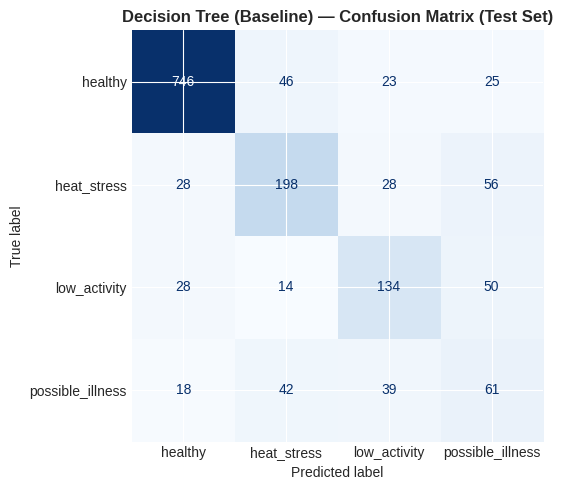

In [22]:
# ─── Train Decision Tree ──────────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,      # unlimited → will overfit
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)

dt_model = evaluate_model(
    'Decision Tree (Baseline)',
    dt_model,
    X_train_sm, y_train_sm,
    X_val, y_val,
    X_test, y_test
)

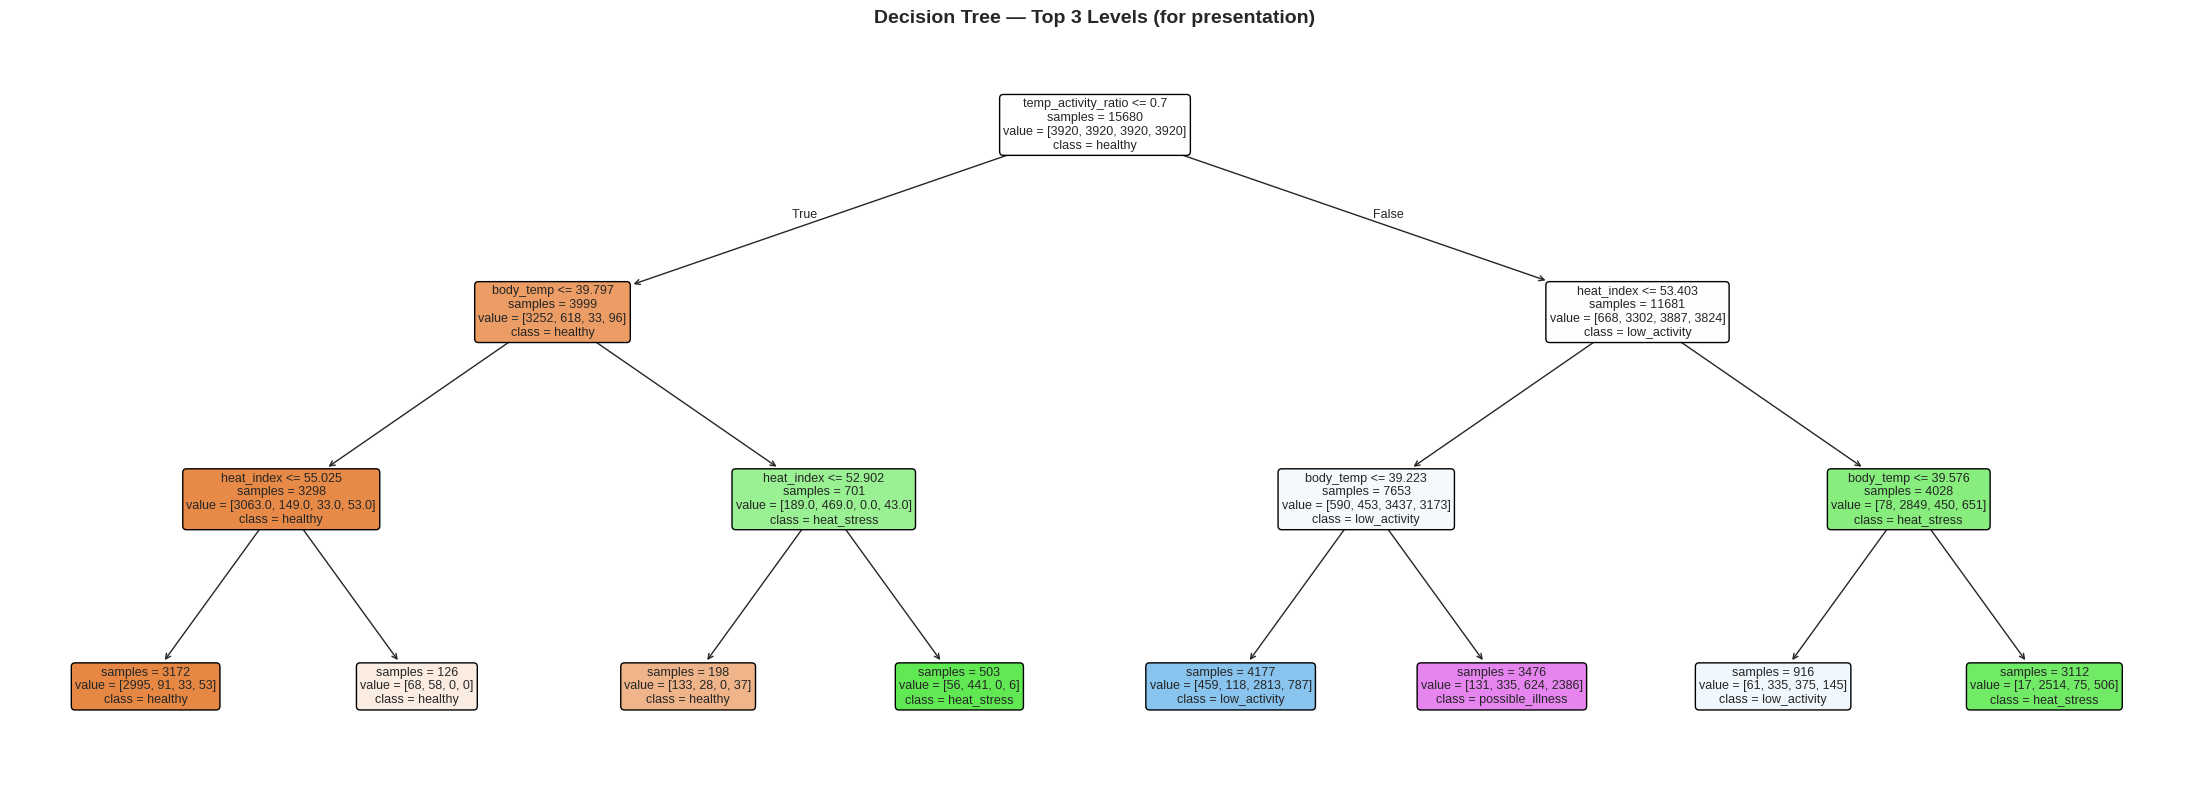


📋 Decision Rules (depth ≤ 3):
|--- temp_activity_ratio <= 0.70
|   |--- body_temp <= 39.80
|   |   |--- heat_index <= 55.02
|   |   |   |--- class: 0
|   |   |--- heat_index >  55.02
|   |   |   |--- class: 0
|   |--- body_temp >  39.80
|   |   |--- heat_index <= 52.90
|   |   |   |--- class: 0
|   |   |--- heat_index >  52.90
|   |   |   |--- class: 1
|--- temp_activity_ratio >  0.70
|   |--- heat_index <= 53.40
|   |   |--- body_temp <= 39.22
|   |   |   |--- class: 2
|   |   |--- body_temp >  39.22
|   |   |   |--- class: 3
|   |--- heat_index >  53.40
|   |   |--- body_temp <= 39.58
|   |   |   |--- class: 2
|   |   |--- body_temp >  39.58
|   |   |   |--- class: 1



In [23]:
# ─── Visualise Decision Tree (depth-limited for readability) ──────────────────
dt_viz = DecisionTreeClassifier(
    max_depth=3, random_state=RANDOM_STATE
).fit(X_train_sm, y_train_sm)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_viz, ax=ax,
    feature_names=FEATURE_COLS,
    class_names=le.classes_,
    filled=True, rounded=True,
    fontsize=9, impurity=False
)
ax.set_title('Decision Tree — Top 3 Levels (for presentation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_decision_tree_viz.png', bbox_inches='tight', dpi=150)
plt.show()

# Text representation of rules
print('\n📋 Decision Rules (depth ≤ 3):')
print(export_text(dt_viz, feature_names=FEATURE_COLS, max_depth=3))

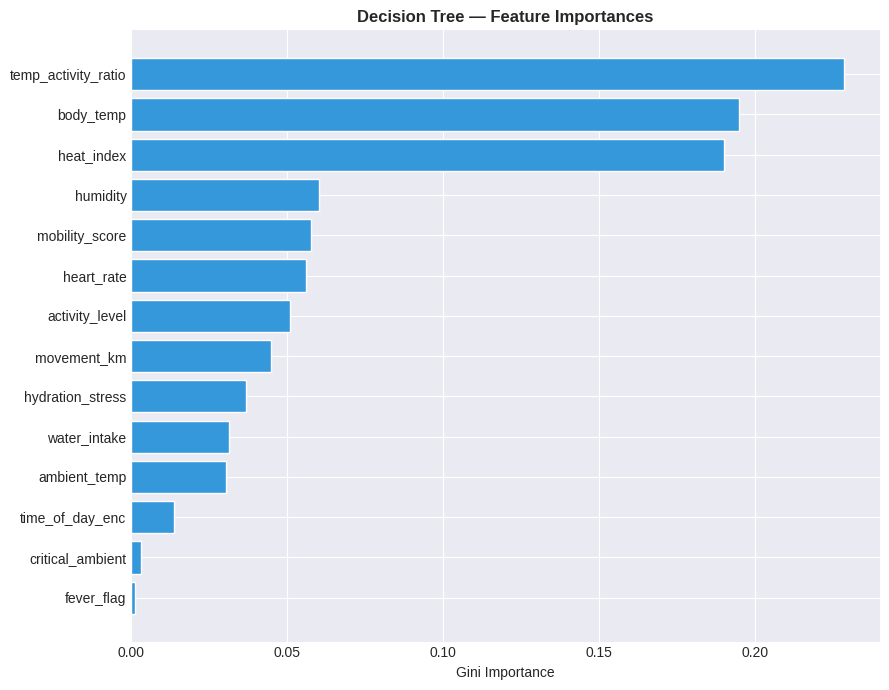

In [24]:
# ─── Decision Tree — Feature Importance ──────────────────────────────────────
dt_importance = pd.Series(
    dt_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(dt_importance.index, dt_importance.values,
               color='#3498db', edgecolor='white')
ax.set_title('Decision Tree — Feature Importances', fontweight='bold')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('06_dt_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 7 — Model 2: Random Forest

> **Purpose:** Ensemble of many decision trees — reduces overfitting via majority voting.


───────────────────────────────────────────────────────
  Model : Random Forest
───────────────────────────────────────────────────────
  Train  Accuracy : 98.65%
  Val    Accuracy : 82.93%
  Test   Accuracy : 81.05%
  Test   F1 Score : 80.93%
  Test   Precision: 80.89%
  Test   Recall   : 81.05%
  Overfit Gap     : 17.59%  ⚠️

  Classification Report (Test Set):
                  precision    recall  f1-score   support

         healthy       0.93      0.92      0.93       840
     heat_stress       0.78      0.78      0.78       310
    low_activity       0.65      0.72      0.69       226
possible_illness       0.45      0.40      0.43       160

        accuracy                           0.81      1536
       macro avg       0.70      0.71      0.70      1536
    weighted avg       0.81      0.81      0.81      1536



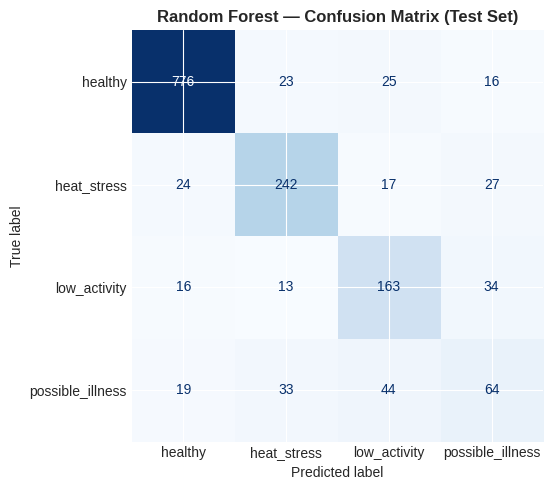

In [25]:
# ─── Train Random Forest ──────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_model = evaluate_model(
    'Random Forest',
    rf_model,
    X_train_sm, y_train_sm,
    X_val, y_val,
    X_test, y_test
)

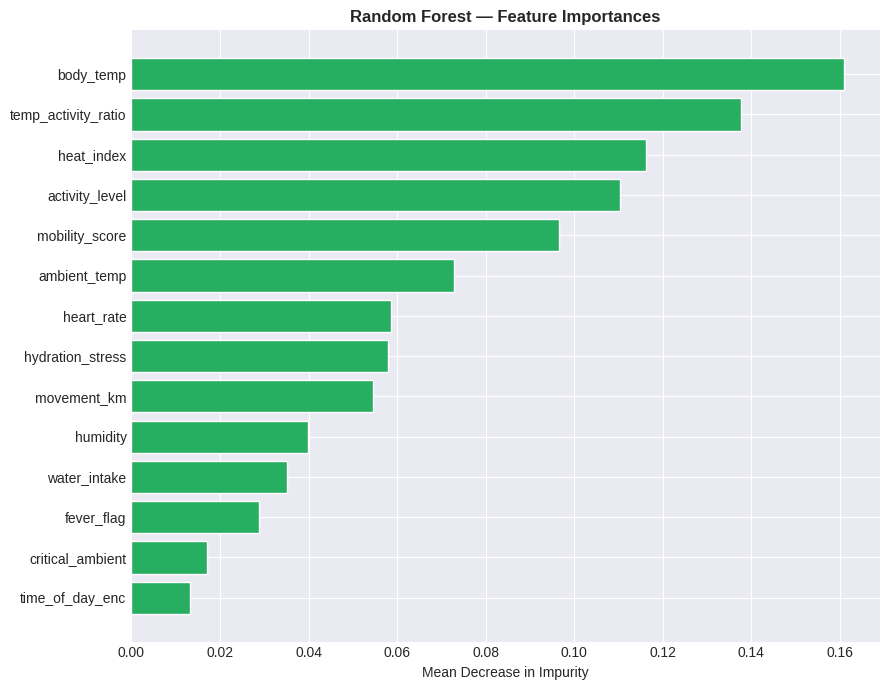

In [26]:
# ─── Random Forest — Feature Importance ──────────────────────────────────────
rf_importance = pd.Series(
    rf_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(rf_importance.index, rf_importance.values,
        color='#27ae60', edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('07_rf_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 8 — Model 3: XGBoost

> **Purpose:** Gradient boosting — typically best overall performance.


───────────────────────────────────────────────────────
  Model : XGBoost
───────────────────────────────────────────────────────
  Train  Accuracy : 95.03%
  Val    Accuracy : 83.13%
  Test   Accuracy : 80.99%
  Test   F1 Score : 80.94%
  Test   Precision: 80.93%
  Test   Recall   : 80.99%
  Overfit Gap     : 14.04%  ⚠️

  Classification Report (Test Set):
                  precision    recall  f1-score   support

         healthy       0.93      0.93      0.93       840
     heat_stress       0.77      0.78      0.78       310
    low_activity       0.65      0.70      0.68       226
possible_illness       0.45      0.42      0.44       160

        accuracy                           0.81      1536
       macro avg       0.70      0.71      0.70      1536
    weighted avg       0.81      0.81      0.81      1536



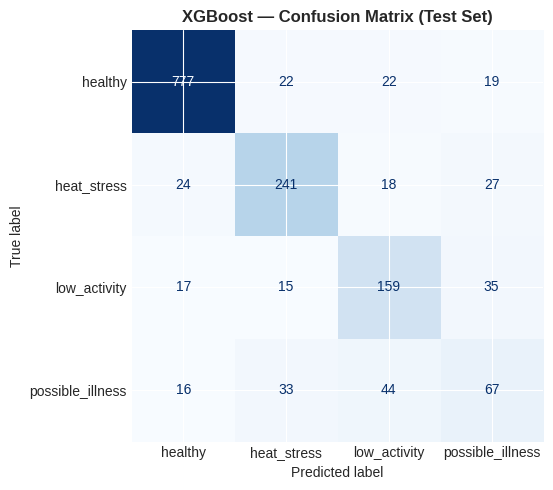

In [27]:
# ─── Train XGBoost ───────────────────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

xgb_model = evaluate_model(
    'XGBoost',
    xgb_model,
    X_train_sm, y_train_sm,
    X_val, y_val,
    X_test, y_test
)

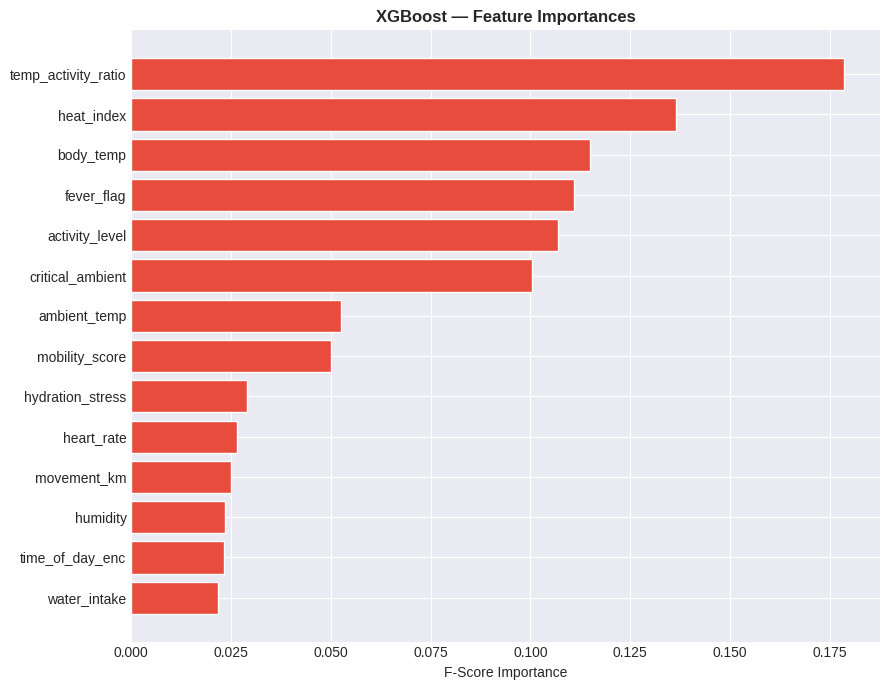

In [28]:
# ─── XGBoost — Feature Importance ────────────────────────────────────────────
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(xgb_importance.index, xgb_importance.values,
        color='#e74c3c', edgecolor='white')
ax.set_title('XGBoost — Feature Importances', fontweight='bold')
ax.set_xlabel('F-Score Importance')
plt.tight_layout()
plt.savefig('08_xgb_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 9 — Model 4: LightGBM

> **Purpose:** Faster gradient boosting — excellent for large datasets.

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2810
[LightGBM] [Info] Number of data points in the train set: 15680, number of used features: 14
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

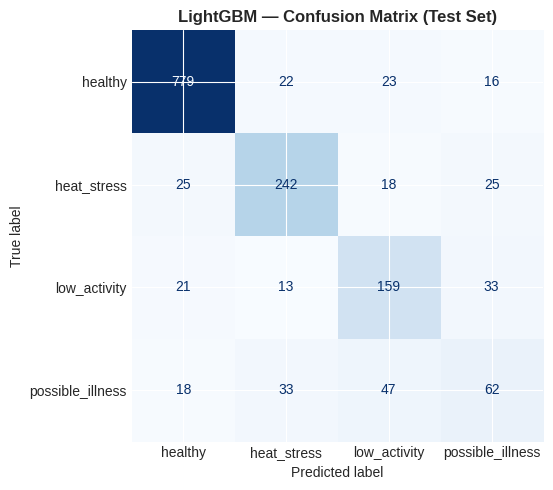

In [29]:
# ─── Train LightGBM ───────────────────────────────────────────────────────────
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

lgbm_model = evaluate_model(
    'LightGBM',
    lgbm_model,
    X_train_sm, y_train_sm,
    X_val, y_val,
    X_test, y_test
)

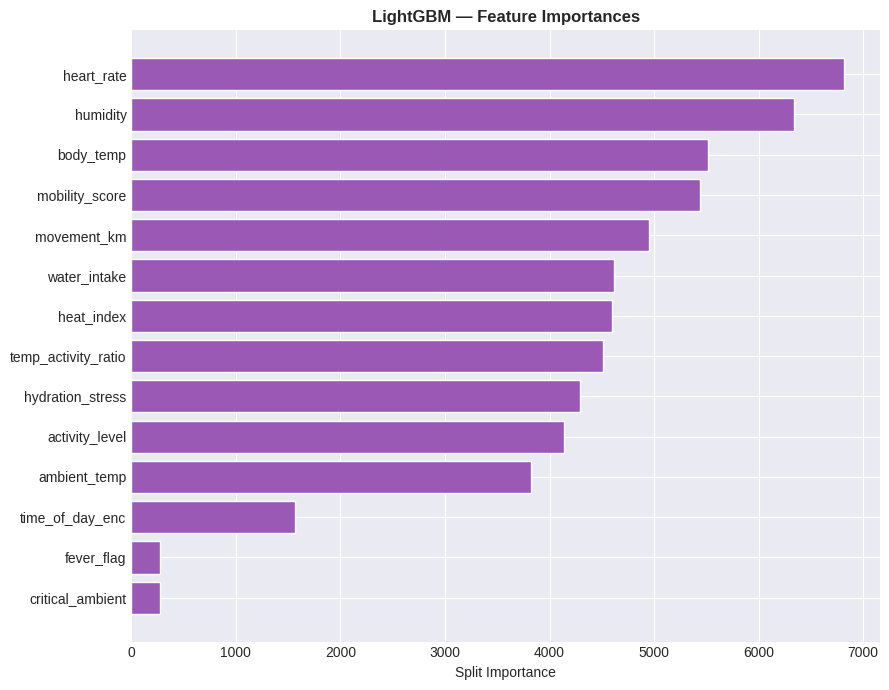

In [30]:
# ─── LightGBM — Feature Importance ───────────────────────────────────────────
lgbm_importance = pd.Series(
    lgbm_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(lgbm_importance.index, lgbm_importance.values,
        color='#9b59b6', edgecolor='white')
ax.set_title('LightGBM — Feature Importances', fontweight='bold')
ax.set_xlabel('Split Importance')
plt.tight_layout()
plt.savefig('09_lgbm_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 10 — Model 5: CatBoost

> **Purpose:** Handles categorical features natively; often best out-of-the-box.


───────────────────────────────────────────────────────
  Model : CatBoost
───────────────────────────────────────────────────────
  Train  Accuracy : 85.91%
  Val    Accuracy : 82.80%
  Test   Accuracy : 81.51%
  Test   F1 Score : 81.43%
  Test   Precision: 81.43%
  Test   Recall   : 81.51%
  Overfit Gap     : 4.40%  ✅

  Classification Report (Test Set):
                  precision    recall  f1-score   support

         healthy       0.94      0.93      0.93       840
     heat_stress       0.77      0.79      0.78       310
    low_activity       0.65      0.71      0.68       226
possible_illness       0.48      0.42      0.45       160

        accuracy                           0.82      1536
       macro avg       0.71      0.71      0.71      1536
    weighted avg       0.81      0.82      0.81      1536



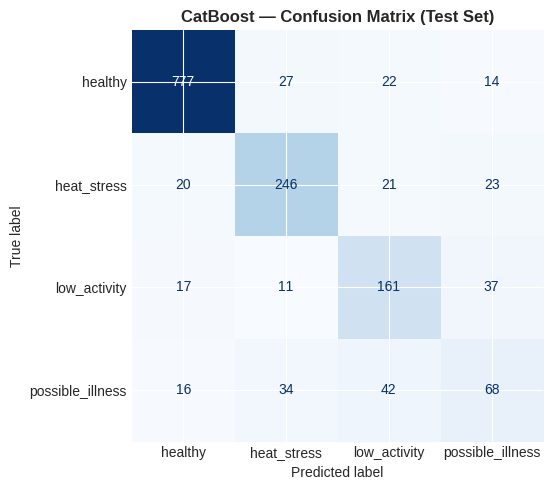

In [31]:
# ─── Train CatBoost ───────────────────────────────────────────────────────────
cat_model = CatBoostClassifier(
    iterations=300,
    depth=7,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0
)

cat_model = evaluate_model(
    'CatBoost',
    cat_model,
    X_train_sm, y_train_sm,
    X_val, y_val,
    X_test, y_test
)

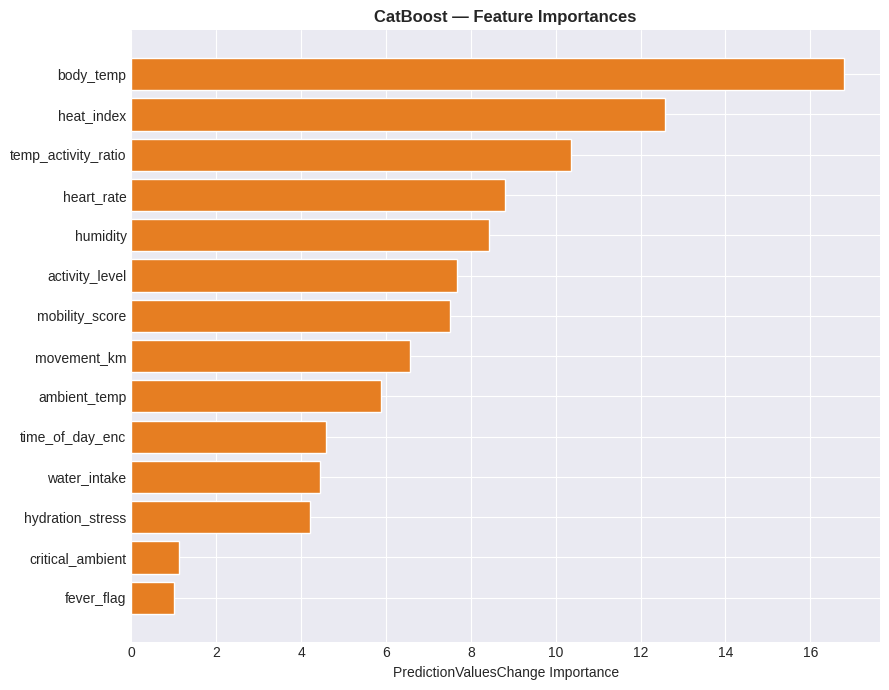

In [32]:
# ─── CatBoost — Feature Importance ───────────────────────────────────────────
cat_importance = pd.Series(
    cat_model.get_feature_importance(),
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(cat_importance.index, cat_importance.values,
        color='#e67e22', edgecolor='white')
ax.set_title('CatBoost — Feature Importances', fontweight='bold')
ax.set_xlabel('PredictionValuesChange Importance')
plt.tight_layout()
plt.savefig('10_catboost_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 11 — Hyperparameter Tuning

We apply **Optuna** (Bayesian Optimisation) to the two best-performing models: **XGBoost** and **CatBoost**.

In [33]:
# ─── 11.1 — Cross-Validated F1 Scorer ────────────────────────────────────────
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_score(model, X, y):
    scores = cross_val_score(
        model, X, y, cv=CV,
        scoring='f1_weighted', n_jobs=-1
    )
    return scores.mean()

print('✅ CV scorer ready — 5-Fold Stratified, metric: F1 (weighted)')

✅ CV scorer ready — 5-Fold Stratified, metric: F1 (weighted)


In [34]:
# ─── 11.2 — Optuna Tuning: XGBoost ───────────────────────────────────────────
N_TRIALS = 40  # increase for better results (e.g. 100 for competition)

def xgb_objective(trial):
    params = dict(
        n_estimators        = trial.suggest_int('n_estimators', 100, 600),
        max_depth           = trial.suggest_int('max_depth', 3, 10),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample           = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree    = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight    = trial.suggest_int('min_child_weight', 1, 10),
        gamma               = trial.suggest_float('gamma', 0, 5),
        reg_alpha           = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda          = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    )
    model = XGBClassifier(
        **params,
        use_label_encoder=False,
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    return cv_score(model, X_train_sm, y_train_sm)

print(f'- Running Optuna XGBoost tuning ({N_TRIALS} trials)...')
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ XGBoost Best CV F1 : {xgb_study.best_value:.4f}')
print(f'   Best params       : {xgb_study.best_params}')

- Running Optuna XGBoost tuning (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]


✅ XGBoost Best CV F1 : 0.8983
   Best params       : {'n_estimators': 340, 'max_depth': 7, 'learning_rate': 0.22440992658398726, 'subsample': 0.6090768026400113, 'colsample_bytree': 0.6863873445228605, 'min_child_weight': 5, 'gamma': 0.023557454018751055, 'reg_alpha': 0.6074810665269268, 'reg_lambda': 2.177827078706092}



───────────────────────────────────────────────────────
  Model : XGBoost (Tuned)
───────────────────────────────────────────────────────
  Train  Accuracy : 100.00%
  Val    Accuracy : 81.30%
  Test   Accuracy : 80.40%
  Test   F1 Score : 80.17%
  Test   Precision: 80.00%
  Test   Recall   : 80.40%
  Overfit Gap     : 19.60%  ⚠️

  Classification Report (Test Set):
                  precision    recall  f1-score   support

         healthy       0.93      0.93      0.93       840
     heat_stress       0.76      0.78      0.77       310
    low_activity       0.64      0.66      0.65       226
possible_illness       0.46      0.39      0.42       160

        accuracy                           0.80      1536
       macro avg       0.69      0.69      0.69      1536
    weighted avg       0.80      0.80      0.80      1536



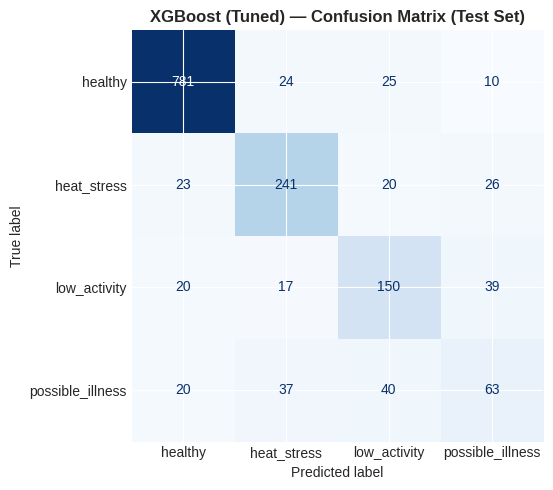

In [35]:
# ─── 11.3 — Train Tuned XGBoost & Evaluate ───────────────────────────────────
best_xgb_params = xgb_study.best_params

xgb_tuned = XGBClassifier(
    **best_xgb_params,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

xgb_tuned = evaluate_model(
    'XGBoost (Tuned)',
    xgb_tuned,
    X_train_sm, y_train_sm,
    X_val, y_val,
    X_test, y_test
)

In [36]:
# ─── 11.4 — Optuna Tuning: CatBoost ──────────────────────────────────────────
def cat_objective(trial):
    params = dict(
        iterations   = trial.suggest_int('iterations', 100, 600),
        depth        = trial.suggest_int('depth', 4, 10),
        learning_rate= trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg  = trial.suggest_float('l2_leaf_reg', 1e-3, 20.0, log=True),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 1e-4, 10.0, log=True),
        border_count        = trial.suggest_int('border_count', 32, 255),
    )
    model = CatBoostClassifier(
        **params,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        auto_class_weights='Balanced',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    return cv_score(model, X_train_sm, y_train_sm)

print(f'- Running Optuna CatBoost tuning ({N_TRIALS} trials)...')
cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ CatBoost Best CV F1 : {cat_study.best_value:.4f}')
print(f'   Best params        : {cat_study.best_params}')

- Running Optuna CatBoost tuning (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]


✅ CatBoost Best CV F1 : 0.9250
   Best params        : {'iterations': 566, 'depth': 10, 'learning_rate': 0.220186409249455, 'l2_leaf_reg': 0.0032410988436083897, 'bagging_temperature': 0.19464616161995352, 'random_strength': 0.00010914370044997586, 'border_count': 176}



───────────────────────────────────────────────────────
  Model : CatBoost (Tuned)
───────────────────────────────────────────────────────
  Train  Accuracy : 100.00%
  Val    Accuracy : 81.56%
  Test   Accuracy : 81.18%
  Test   F1 Score : 80.89%
  Test   Precision: 80.70%
  Test   Recall   : 81.18%
  Overfit Gap     : 18.82%  ⚠️

  Classification Report (Test Set):
                  precision    recall  f1-score   support

         healthy       0.92      0.94      0.93       840
     heat_stress       0.77      0.76      0.77       310
    low_activity       0.65      0.69      0.67       226
possible_illness       0.51      0.43      0.47       160

        accuracy                           0.81      1536
       macro avg       0.71      0.70      0.71      1536
    weighted avg       0.81      0.81      0.81      1536



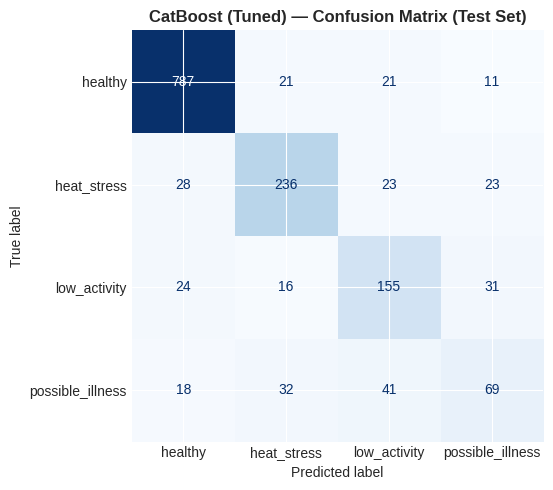

In [37]:
# ─── 11.5 — Train Tuned CatBoost & Evaluate ──────────────────────────────────
best_cat_params = cat_study.best_params

cat_tuned = CatBoostClassifier(
    **best_cat_params,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0
)

cat_tuned = evaluate_model(
    'CatBoost (Tuned)',
    cat_tuned,
    X_train_sm, y_train_sm,
    X_val, y_val,
    X_test, y_test
)

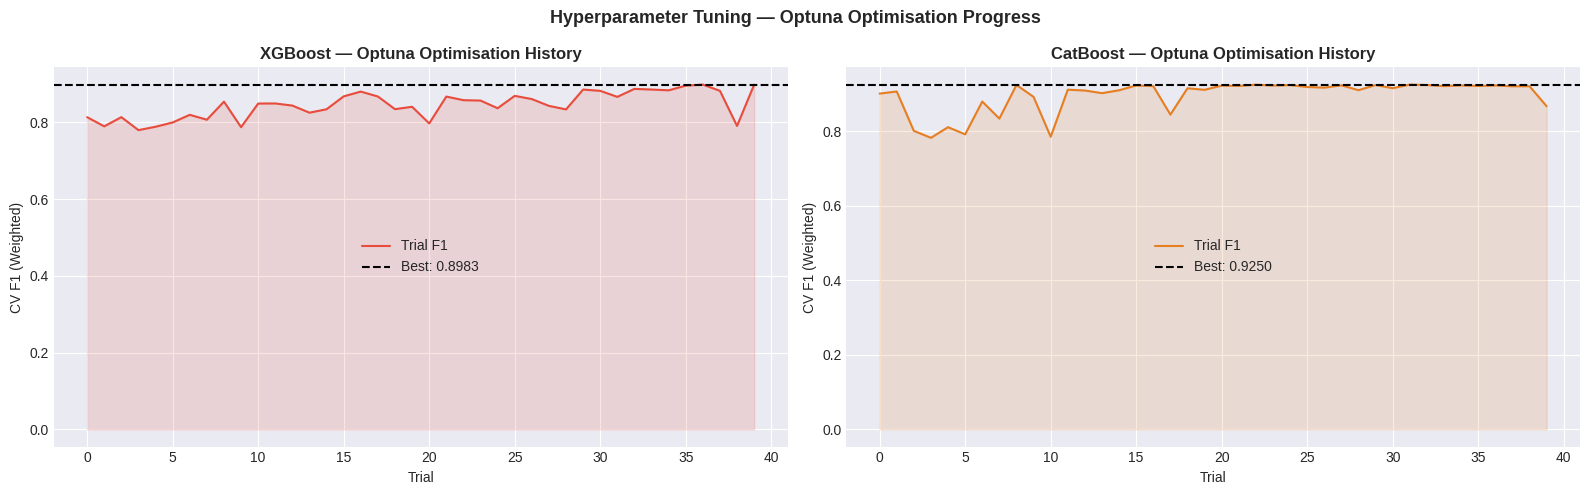

In [38]:
# ─── 11.6 — Optuna Visualisation: Optimisation History ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# XGBoost
xgb_vals = [t.value for t in xgb_study.trials if t.value is not None]
axes[0].plot(xgb_vals, color='#e74c3c', linewidth=1.5, label='Trial F1')
axes[0].axhline(xgb_study.best_value, color='black', linestyle='--', label=f'Best: {xgb_study.best_value:.4f}')
axes[0].fill_between(range(len(xgb_vals)), xgb_vals, alpha=0.15, color='#e74c3c')
axes[0].set_title('XGBoost — Optuna Optimisation History', fontweight='bold')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV F1 (Weighted)')
axes[0].legend()

# CatBoost
cat_vals = [t.value for t in cat_study.trials if t.value is not None]
axes[1].plot(cat_vals, color='#e67e22', linewidth=1.5, label='Trial F1')
axes[1].axhline(cat_study.best_value, color='black', linestyle='--', label=f'Best: {cat_study.best_value:.4f}')
axes[1].fill_between(range(len(cat_vals)), cat_vals, alpha=0.15, color='#e67e22')
axes[1].set_title('CatBoost — Optuna Optimisation History', fontweight='bold')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('CV F1 (Weighted)')
axes[1].legend()

plt.suptitle('Hyperparameter Tuning — Optuna Optimisation Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('11_optuna_history.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 12 — Final Model Comparison & Selection

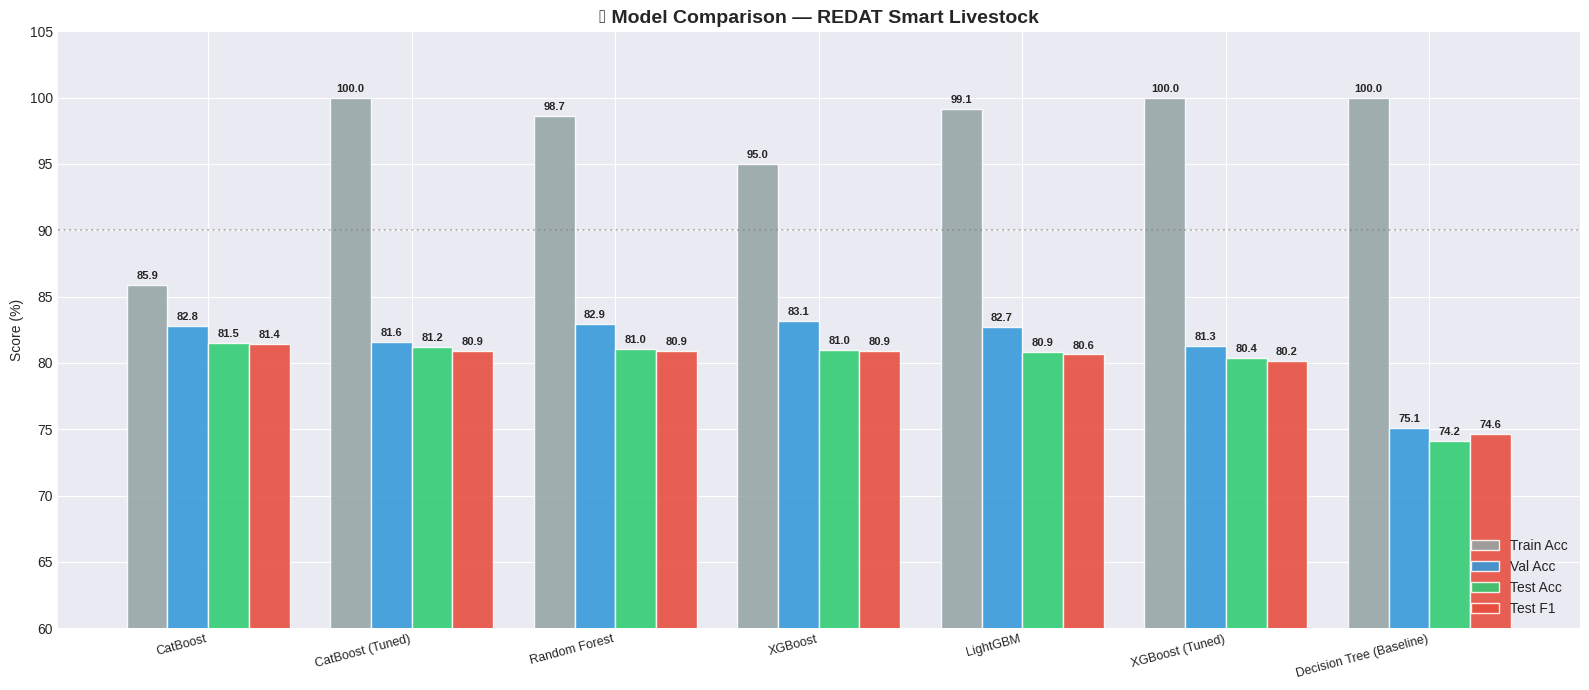

In [40]:
# ─── Visual Comparison Chart ──────────────────────────────────────────────────
models_plot = results_df['Model'].tolist()
metrics = ['Train Acc', 'Val Acc', 'Test Acc', 'Test F1']
metric_colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']

x = np.arange(len(models_plot))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = results_df[metric].tolist()
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models_plot, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_ylim(60, 105)
ax.set_title('🏆 Model Comparison — REDAT Smart Livestock', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(y=90, color='gray', linestyle=':', alpha=0.5, label='90% reference')

plt.tight_layout()
plt.savefig('12_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

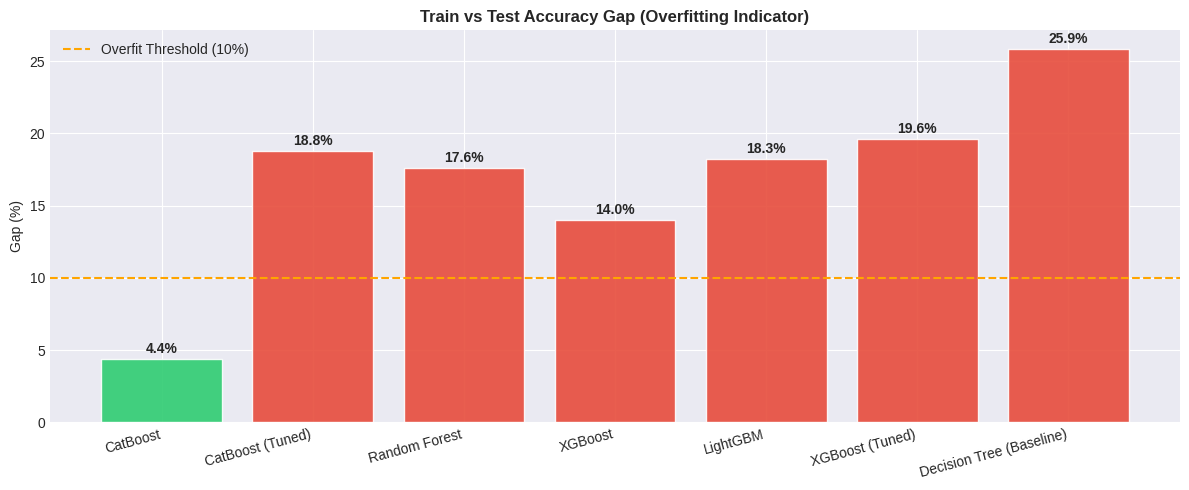

In [41]:
# ─── Overfitting Gap Chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
gap_vals = results_df['Train-Test Gap'].tolist()
colors = ['#e74c3c' if g > 10 else '#2ecc71' for g in gap_vals]
bars = ax.bar(models_plot, gap_vals, color=colors, edgecolor='white', alpha=0.9)
ax.axhline(y=10, color='orange', linestyle='--', linewidth=1.5, label='Overfit Threshold (10%)')
ax.set_title('Train vs Test Accuracy Gap (Overfitting Indicator)', fontweight='bold')
ax.set_ylabel('Gap (%)')
ax.set_xticklabels(models_plot, rotation=15, ha='right')
ax.legend()
for bar, val in zip(bars, gap_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('13_overfit_gap.png', bbox_inches='tight', dpi=150)
plt.show()

In [42]:
# ─── Cross-Validation Scores (Best 3 Models) ─────────────────────────────────
top_models = {
    'XGBoost (Tuned)' : xgb_tuned,
    'CatBoost (Tuned)': cat_tuned,
    'Random Forest'   : rf_model,
}

print('5-Fold Stratified Cross-Validation (weighted F1) on full training data:')
print('-' * 55)
cv_results = {}
for name, model in top_models.items():
    scores = cross_val_score(
        model, X_train_sm, y_train_sm,
        cv=CV, scoring='f1_weighted', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'  {name:<22}  Mean: {scores.mean()*100:.2f}%  Std: {scores.std()*100:.2f}%')

5-Fold Stratified Cross-Validation (weighted F1) on full training data:
-------------------------------------------------------
  XGBoost (Tuned)         Mean: 89.83%  Std: 0.24%
  CatBoost (Tuned)        Mean: 92.50%  Std: 0.20%
  Random Forest           Mean: 86.82%  Std: 0.41%


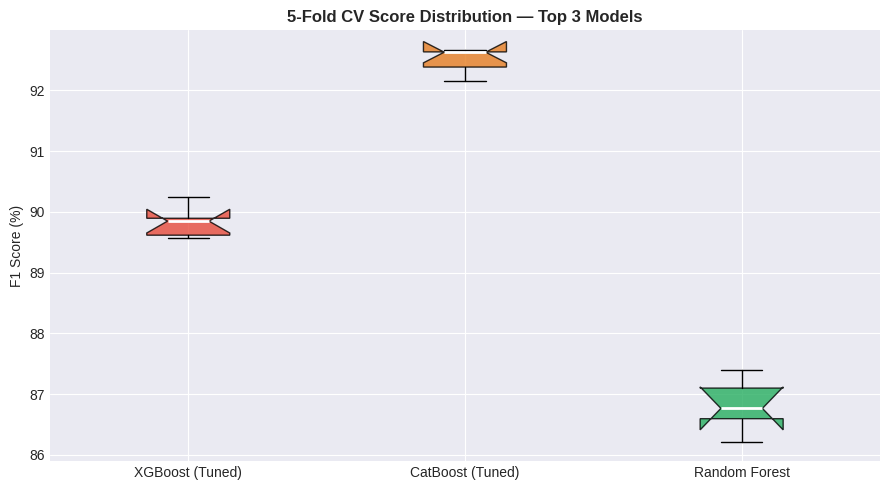

In [43]:
# ─── CV Boxplot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
data_cv  = [v * 100 for v in cv_results.values()]
labels_cv = list(cv_results.keys())
bp = ax.boxplot(data_cv, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2))
box_colors = ['#e74c3c', '#e67e22', '#27ae60']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(labels_cv, fontsize=10)
ax.set_ylabel('F1 Score (%)')
ax.set_title('5-Fold CV Score Distribution — Top 3 Models', fontweight='bold')
plt.tight_layout()
plt.savefig('14_cv_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

In [50]:
# ─── Presentation Table (Markdown style) ─────────────────────────────────────
print('''
  📊 REDAT Presentation Table''')
print('  ' + '─' * 75)
header = f'  {"Model":<28} {"Test Acc":>10} {"F1 Score":>10} {"Gap":>8}'
print(header)
print('  ' + '─' * 75)
for _, row in results_df.iterrows():
    flag = '🏆' if row['Model'] == results_df.iloc[0]['Model'] else '  '
    print(f'  {flag} {row["Model"]:<26} {row["Test Acc"]:>9.2f}%  {row["Test F1"]:>9.2f}%  {row["Train-Test Gap"]:>7.2f}%')
print('  ' + '─' * 75)


  📊 REDAT Presentation Table
  ───────────────────────────────────────────────────────────────────────────
  Model                          Test Acc   F1 Score      Gap
  ───────────────────────────────────────────────────────────────────────────
  🏆 CatBoost                       81.51%      81.43%     4.40%
     CatBoost (Tuned)               81.18%      80.89%    18.82%
     Random Forest                  81.05%      80.93%    17.59%
     XGBoost                        80.99%      80.94%    14.04%
     LightGBM                       80.86%      80.64%    18.26%
     XGBoost (Tuned)                80.40%      80.17%    19.60%
     Decision Tree (Baseline)       74.15%      74.63%    25.85%
  ───────────────────────────────────────────────────────────────────────────


---
## Section 13 — Save Best Model

In [45]:
# ─── Identify Best Model ──────────────────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
print(f'Best model selected: {best_model_name}')

best_model_obj = {
    'Decision Tree (Baseline)' : dt_model,
    'Random Forest'            : rf_model,
    'XGBoost'                  : xgb_model,
    'LightGBM'                 : lgbm_model,
    'CatBoost'                 : cat_model,
    'XGBoost (Tuned)'          : xgb_tuned,
    'CatBoost (Tuned)'         : cat_tuned,
}.get(best_model_name, xgb_tuned)

# Save model + scaler + label encoder + feature list
os.makedirs('saved_model', exist_ok=True)

joblib.dump(best_model_obj, 'saved_model/redat_best_model.pkl')
joblib.dump(scaler,         'saved_model/redat_scaler.pkl')
joblib.dump(le,             'saved_model/redat_label_encoder.pkl')
joblib.dump(FEATURE_COLS,   'saved_model/redat_feature_cols.pkl')

# Also save as CatBoost native format if CatBoost
if 'CatBoost' in best_model_name:
    best_model_obj.save_model('saved_model/redat_catboost.cbm')
    print('  → Also saved as native CatBoost .cbm format.')

print('\n✅ Saved files:')
for f in os.listdir('saved_model'):
    size = os.path.getsize(f'saved_model/{f}') / 1024
    print(f'  saved_model/{f}  ({size:.1f} KB)')

Best model selected: CatBoost
  → Also saved as native CatBoost .cbm format.

✅ Saved files:
  saved_model/redat_scaler.pkl  (1.4 KB)
  saved_model/redat_label_encoder.pkl  (0.5 KB)
  saved_model/redat_best_model.pkl  (1550.1 KB)
  saved_model/redat_feature_cols.pkl  (0.2 KB)
  saved_model/redat_catboost.cbm  (1549.5 KB)


In [46]:
# ─── Quick Inference Test ─────────────────────────────────────────────────────
# Simulate a new camel reading from the collar
sample_readings = pd.DataFrame([{
    'body_temp'        : 41.2,   # elevated — fever territory
    'activity_level'   : 20,     # very low
    'heart_rate'       : 105,    # elevated
    'movement_km'      : 0.5,
    'ambient_temp'     : 47.0,   # extreme UAE summer heat
    'humidity'         : 25.0,
    'water_intake'     : 8.0,    # low hydration
    'time_of_day_enc'  : 1,      # afternoon
    # Engineered
    'heat_index'       : 41.2 + 0.33 * 47.0,
    'temp_activity_ratio': 41.2 / (20 + 1),
    'hydration_stress' : 47.0 / (8.0 + 1),
    'mobility_score'   : 0.5 * 20,
    'fever_flag'       : 1,
    'critical_ambient' : 1,
}])[FEATURE_COLS]

prediction_enc = best_model_obj.predict(sample_readings)[0]
prediction_lbl = le.inverse_transform([int(prediction_enc)])[0]

emoji_map = {
    'healthy'          : '✅ Healthy',
    'heat_stress'      : '🔴 HEAT STRESS — Alert Farmer!',
    'possible_illness' : '🟠 Possible Illness — Monitor Closely',
    'low_activity'     : '🟡 Low Activity — Check Camel'
}

print('🐪 REDAT Smart Livestock Collar Reading — AI Prediction')
print('─' * 45)
print(f'  Body Temp    : 41.2°C')
print(f'  Activity     : 20 / 100')
print(f'  Ambient Temp : 47.0°C')
print(f'  Heart Rate   : 105 bpm')
print('─' * 45)
print(f'  AI Prediction: {emoji_map.get(prediction_lbl, prediction_lbl)}')
print('─' * 45)

🐪 REDAT Smart Livestock Collar Reading — AI Prediction
─────────────────────────────────────────────
  Body Temp    : 41.2°C
  Activity     : 20 / 100
  Ambient Temp : 47.0°C
  Heart Rate   : 105 bpm
─────────────────────────────────────────────
  AI Prediction: 🔴 HEAT STRESS — Alert Farmer!
─────────────────────────────────────────────


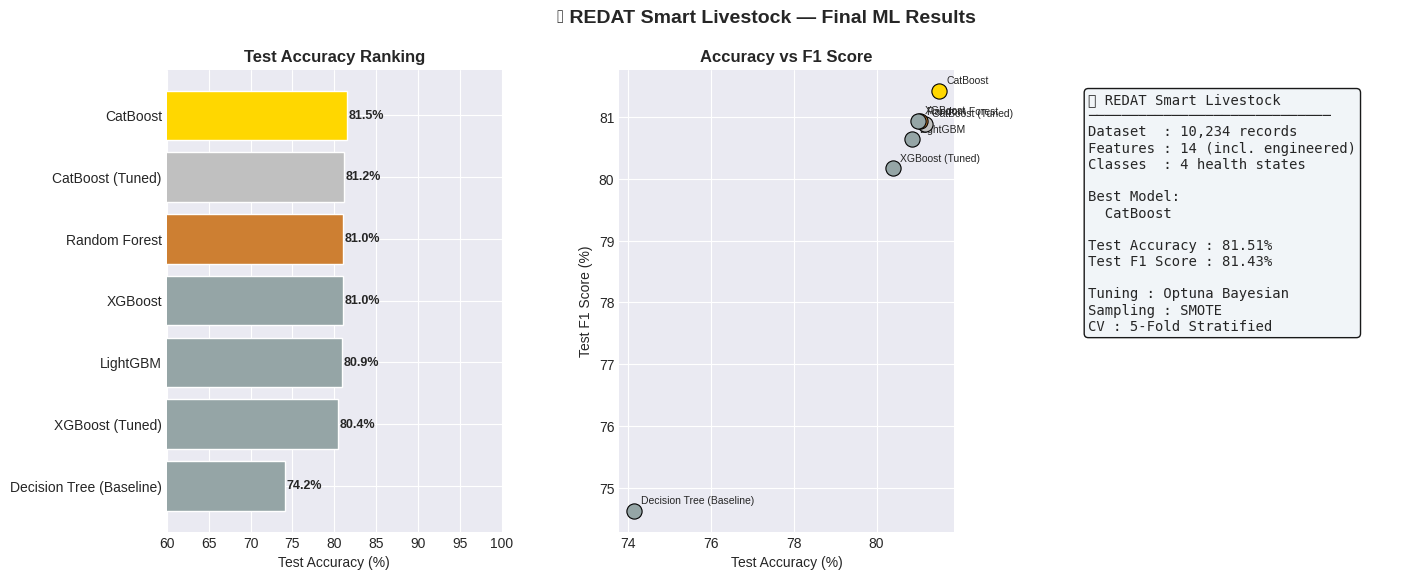


🎉 Notebook complete! All models trained, tuned, and evaluated.
   Your best model is saved in: saved_model/


In [47]:
# ─── Final Summary Plot ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

# 1. Test Accuracy bar
ax1 = fig.add_subplot(gs[0])
colors_rank = ['gold' if i == 0 else 'silver' if i == 1 else '#cd7f32' if i == 2 else '#95a5a6'
               for i in range(len(results_df))]
ax1.barh(results_df['Model'][::-1], results_df['Test Acc'][::-1],
         color=colors_rank[::-1], edgecolor='white')
ax1.set_xlabel('Test Accuracy (%)')
ax1.set_title('Test Accuracy Ranking', fontweight='bold')
ax1.set_xlim(60, 100)
for i, (val, model) in enumerate(zip(results_df['Test Acc'][::-1], results_df['Model'][::-1])):
    ax1.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# 2. F1 vs Accuracy scatter
ax2 = fig.add_subplot(gs[1])
for i, row in results_df.iterrows():
    ax2.scatter(row['Test Acc'], row['Test F1'], s=120,
                color=colors_rank[i-1], zorder=5, edgecolors='black', linewidth=0.8)
    ax2.annotate(row['Model'], (row['Test Acc'], row['Test F1']),
                 textcoords='offset points', xytext=(5, 5), fontsize=7.5)
ax2.set_xlabel('Test Accuracy (%)')
ax2.set_ylabel('Test F1 Score (%)')
ax2.set_title('Accuracy vs F1 Score', fontweight='bold')

# 3. Project info
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
info_text = (
    "🐪 REDAT Smart Livestock\n"
    "─────────────────────────────\n"
    f"Dataset  : {len(df):,} records\n"
    f"Features : {len(FEATURE_COLS)} (incl. engineered)\n"
    f"Classes  : 4 health states\n\n"
    f"Best Model:\n"
    f"  {results_df.iloc[0]['Model']}\n\n"
    f"Test Accuracy : {results_df.iloc[0]['Test Acc']}%\n"
    f"Test F1 Score : {results_df.iloc[0]['Test F1']}%\n\n"
    "Tuning : Optuna Bayesian\n"
    "Sampling : SMOTE\n"
    "CV : 5-Fold Stratified"
)
ax3.text(0.05, 0.95, info_text, transform=ax3.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.9))

plt.suptitle('🏆 REDAT Smart Livestock — Final ML Results', fontsize=14, fontweight='bold')
plt.savefig('15_final_summary.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n🎉 Notebook complete! All models trained, tuned, and evaluated.')
print('   Your best model is saved in: saved_model/')

In [48]:
import shutil
from google.colab import files

# Define the directory containing the saved model and related files
model_dir = 'saved_model'
archive_name = 'redat_smart_livestock_model'

# Create a zip archive of the model directory
shutil.make_archive(archive_name, 'zip', model_dir)

print(f'✅ Model and related files archived to {archive_name}.zip')

# Download the zip file
files.download(f'{archive_name}.zip')

print('📥 Your model archive has been downloaded.')

✅ Model and related files archived to redat_smart_livestock_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Your model archive has been downloaded.
